In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV


In [9]:
data = load_breast_cancer()

X = pd.DataFrame(data.data,
                 columns=data.feature_names)

y = data.target

(X.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [19]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

In [20]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 7, 'n_estimators': 50}


In [21]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    'Precision': [
        lr_precision,
        rf_precision,
        gb_precision
    ],

    'Recall': [
        lr_recall,
        rf_recall,
        gb_recall
    ],

    'F1 Score': [
        lr_f1,
        rf_f1,
        gb_f1
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
1        Random Forest  0.964912   0.958904  0.985915  0.972222
2    Gradient Boosting  0.956140   0.958333  0.971831  0.965035


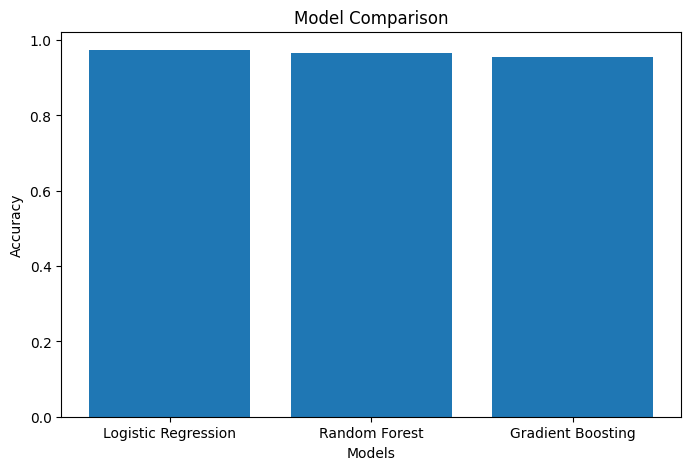

In [22]:
models = [
    'Logistic Regression',
    'Random Forest',
    'Gradient Boosting'
]

accuracy = [
    lr_accuracy,
    rf_accuracy,
    gb_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [52]:
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=3
)

print(rf_cv)
print("Average CV Score:",rf_cv.mean())

[0.93157895 0.96842105 0.96296296]
Average CV Score: 0.9543209876543209


In [53]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
27  worst concave points    0.145743
22       worst perimeter    0.117903
23            worst area    0.102403
7    mean concave points    0.097075
20          worst radius    0.076082
3              mean area    0.073001
2         mean perimeter    0.055024
0            mean radius    0.054159
6         mean concavity    0.046111
26       worst concavity    0.036044


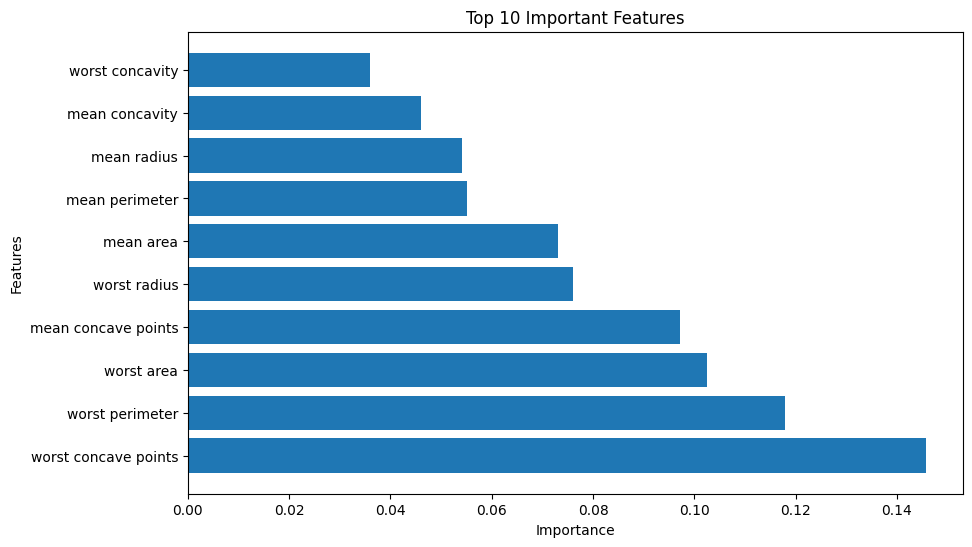

In [54]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title("Top 10 Important Features")

plt.show()

Among all models, Random Forest achieved
high accuracy, strong F1-score,
stable cross-validation performance,
and good interpretability through
feature importance analysis.

Therefore, Random Forest was selected
as the final model.